# HW2 Fashion Enhance (Clean)

This notebook organizes experiments for Fashion-MNIST with clear steps and plots after each feature engineering stage.

In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from skimage.feature import hog


In [2]:
# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
# Data loading
PROJECT_DATA_DIR = './data'
os.makedirs(PROJECT_DATA_DIR, exist_ok=True)
os.environ['KERAS_HOME'] = PROJECT_DATA_DIR

from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print('Fashion-MNIST loaded:', X_train.shape, y_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Fashion-MNIST loaded: (60000, 28, 28) (60000,)


In [5]:
def describe_raw(name, X, y):
    print(f'{name}')
    print(f'  X shape: {X.shape}, dtype: {X.dtype}')
    print(f'  y shape: {y.shape}, dtype: {y.dtype}')
    print(f'  X min/max: {X.min()} / {X.max()}')
    print(f'  Unique labels: {np.unique(y)}')

describe_raw('Fashion-MNIST (raw)', X_train, y_train)

Fashion-MNIST (raw)
  X shape: (60000, 28, 28), dtype: uint8
  y shape: (60000,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [6]:
def show_samples(title, images, labels=None, n=8, cmap='gray'):
    n = min(n, len(images))
    plt.figure(figsize=(n * 2, 2.5))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i], cmap=cmap)
        if labels is not None:
            plt.title(str(labels[i]))
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## Baseline (Raw Pixels)

In [7]:
class FashionDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        if len(data.shape) == 2:
            self.data = data.reshape(-1, 28, 28).astype(np.uint8)
        else:
            self.data = data.astype(np.uint8)
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.data[idx]
        if self.transform:
            image = self.transform(transforms.ToPILImage()(image))
        else:
            image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0
        return image, torch.tensor(self.labels[idx], dtype=torch.long)

In [8]:
class BaselineANN(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=512, output_size=10):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.bn2 = nn.BatchNorm1d(hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc4 = nn.Linear(128, output_size)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        return self.fc4(x)

In [9]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    num_batches = 0
    for X, y in dataloader:
        X = X.to(device).flatten(1)
        y = y.to(device)
        preds = model(X)
        loss = criterion(preds, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(preds, 1)
        acc = (predicted == y).sum().item() / len(y)
        total_loss += loss.item()
        total_acc += acc
        num_batches += 1
    return total_loss / num_batches, total_acc / num_batches

def train_model(model, dataloader, epochs=20, lr=0.001, save_best=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    best_loss = float('inf')
    for epoch in range(epochs):
        loss, acc = train_epoch(model, dataloader, optimizer, criterion)
        print(f'Epoch {epoch+1}/{epochs} - Loss: {loss:.4f}, Acc: {acc:.4f}')
        if save_best and loss < best_loss:
            best_loss = loss
            torch.save(copy.deepcopy(model.state_dict()), save_best)
    return model

def evaluate_model(model, X_test, y_test, num_classes=10, is_raw=True):
    model.eval()
    with torch.no_grad():
        if is_raw:
            inputs = torch.tensor(X_test, dtype=torch.float32).flatten(1).to(device) / 255.0
        else:
            inputs = torch.tensor(X_test, dtype=torch.float32).to(device)
            if inputs.dim() == 3:
                inputs = inputs.flatten(1) / 255.0
        labels = torch.tensor(y_test).to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        pred_cpu = predicted.cpu().numpy()
        labels_cpu = labels.cpu().numpy()
        accuracy = (pred_cpu == labels_cpu).mean()
        f1 = f1_score(labels_cpu, pred_cpu, average='weighted')
        precision = precision_score(labels_cpu, pred_cpu, average='weighted')
        recall = recall_score(labels_cpu, pred_cpu, average='weighted')
        cm = confusion_matrix(labels_cpu, pred_cpu)
        print(f'Accuracy: {accuracy:.4f}')
        print(f'F1 Score: {f1:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()
        return accuracy, f1, precision, recall, cm

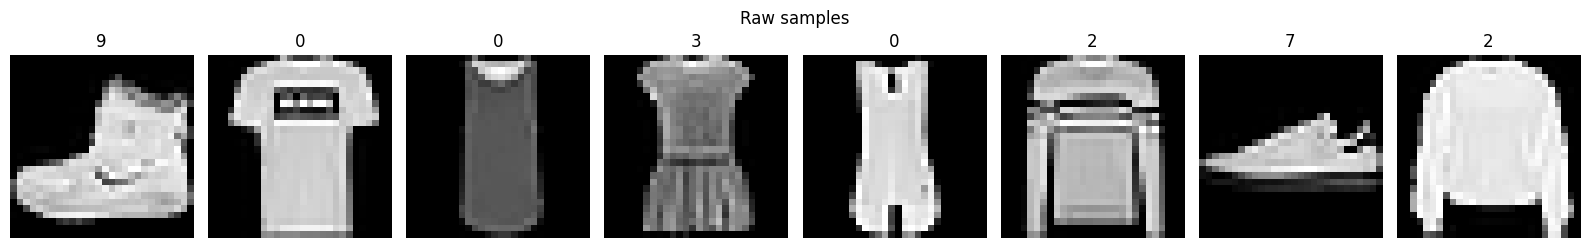

In [10]:
show_samples('Raw samples', X_train[:8], y_train[:8])

In [11]:
train_dataset = FashionDataset(X_train, y_train, transform=None)
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True, num_workers=2)

baseline_model = BaselineANN().to(device)
train_model(baseline_model, train_loader, epochs=30, lr=0.001, save_best='best_fashion_baseline.pth')

Epoch 1/30 - Loss: 0.7612, Acc: 0.7760
Epoch 2/30 - Loss: 0.3933, Acc: 0.8685
Epoch 3/30 - Loss: 0.3226, Acc: 0.8879
Epoch 4/30 - Loss: 0.2864, Acc: 0.8988
Epoch 5/30 - Loss: 0.2548, Acc: 0.9096
Epoch 6/30 - Loss: 0.2332, Acc: 0.9161
Epoch 7/30 - Loss: 0.2172, Acc: 0.9219
Epoch 8/30 - Loss: 0.1971, Acc: 0.9289
Epoch 9/30 - Loss: 0.1800, Acc: 0.9348
Epoch 10/30 - Loss: 0.1653, Acc: 0.9403
Epoch 11/30 - Loss: 0.1569, Acc: 0.9439
Epoch 12/30 - Loss: 0.1471, Acc: 0.9468
Epoch 13/30 - Loss: 0.1323, Acc: 0.9535
Epoch 14/30 - Loss: 0.1157, Acc: 0.9598
Epoch 15/30 - Loss: 0.1065, Acc: 0.9626
Epoch 16/30 - Loss: 0.1050, Acc: 0.9621
Epoch 17/30 - Loss: 0.0891, Acc: 0.9697
Epoch 18/30 - Loss: 0.0900, Acc: 0.9690
Epoch 19/30 - Loss: 0.0820, Acc: 0.9713
Epoch 20/30 - Loss: 0.0738, Acc: 0.9744
Epoch 21/30 - Loss: 0.0786, Acc: 0.9725
Epoch 22/30 - Loss: 0.0614, Acc: 0.9787
Epoch 23/30 - Loss: 0.0688, Acc: 0.9757
Epoch 24/30 - Loss: 0.0546, Acc: 0.9815
Epoch 25/30 - Loss: 0.0497, Acc: 0.9830
Epoch 26/

BaselineANN(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)

Accuracy: 0.8814
F1 Score: 0.8812
Precision: 0.8846
Recall: 0.8814


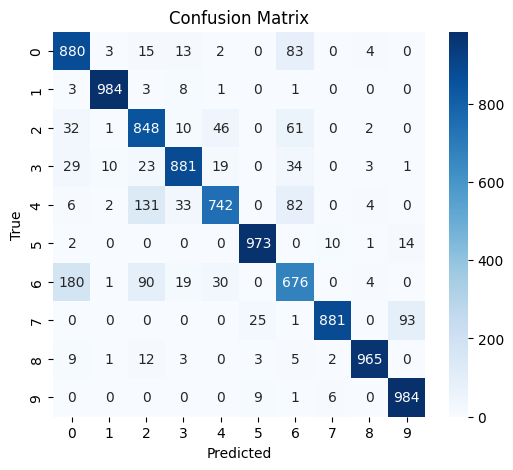

(np.float64(0.8814),
 0.8812099483830329,
 0.8845714318140906,
 0.8814,
 array([[880,   3,  15,  13,   2,   0,  83,   0,   4,   0],
        [  3, 984,   3,   8,   1,   0,   1,   0,   0,   0],
        [ 32,   1, 848,  10,  46,   0,  61,   0,   2,   0],
        [ 29,  10,  23, 881,  19,   0,  34,   0,   3,   1],
        [  6,   2, 131,  33, 742,   0,  82,   0,   4,   0],
        [  2,   0,   0,   0,   0, 973,   0,  10,   1,  14],
        [180,   1,  90,  19,  30,   0, 676,   0,   4,   0],
        [  0,   0,   0,   0,   0,  25,   1, 881,   0,  93],
        [  9,   1,  12,   3,   0,   3,   5,   2, 965,   0],
        [  0,   0,   0,   0,   0,   9,   1,   6,   0, 984]]))

In [12]:
evaluate_model(baseline_model, X_test, y_test, num_classes=10, is_raw=True)

## Feature Engineering 1: Canny Edges

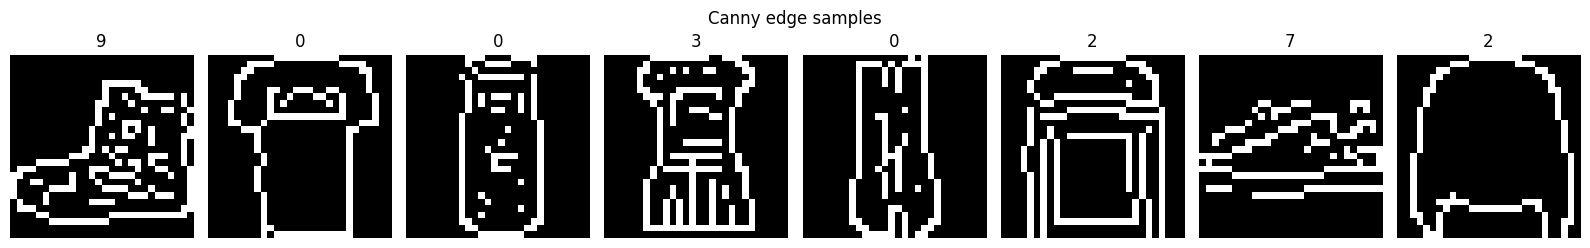

In [13]:
def auto_canny(image, sigma=0.2):
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return cv2.Canny(image, lower, upper)

X_train_edge = np.array([auto_canny(img) for img in X_train], dtype=np.uint8)
X_test_edge = np.array([auto_canny(img) for img in X_test], dtype=np.uint8)

show_samples('Canny edge samples', X_train_edge[:8], y_train[:8])

Epoch 1/30 - Loss: 0.9062, Acc: 0.7117
Epoch 2/30 - Loss: 0.4794, Acc: 0.8365
Epoch 3/30 - Loss: 0.3682, Acc: 0.8748
Epoch 4/30 - Loss: 0.2779, Acc: 0.9075
Epoch 5/30 - Loss: 0.2013, Acc: 0.9357
Epoch 6/30 - Loss: 0.1387, Acc: 0.9574
Epoch 7/30 - Loss: 0.0904, Acc: 0.9747
Epoch 8/30 - Loss: 0.0595, Acc: 0.9841
Epoch 9/30 - Loss: 0.0452, Acc: 0.9875
Epoch 10/30 - Loss: 0.0308, Acc: 0.9922
Epoch 11/30 - Loss: 0.0186, Acc: 0.9961
Epoch 12/30 - Loss: 0.0126, Acc: 0.9976
Epoch 13/30 - Loss: 0.0075, Acc: 0.9991
Epoch 14/30 - Loss: 0.0064, Acc: 0.9991
Epoch 15/30 - Loss: 0.0052, Acc: 0.9992
Epoch 16/30 - Loss: 0.0057, Acc: 0.9989
Epoch 17/30 - Loss: 0.0088, Acc: 0.9978
Epoch 18/30 - Loss: 0.0118, Acc: 0.9969
Epoch 19/30 - Loss: 0.0199, Acc: 0.9939
Epoch 20/30 - Loss: 0.0293, Acc: 0.9905
Epoch 21/30 - Loss: 0.0294, Acc: 0.9907
Epoch 22/30 - Loss: 0.0295, Acc: 0.9908
Epoch 23/30 - Loss: 0.0206, Acc: 0.9936
Epoch 24/30 - Loss: 0.0198, Acc: 0.9939
Epoch 25/30 - Loss: 0.0208, Acc: 0.9934
Epoch 26/

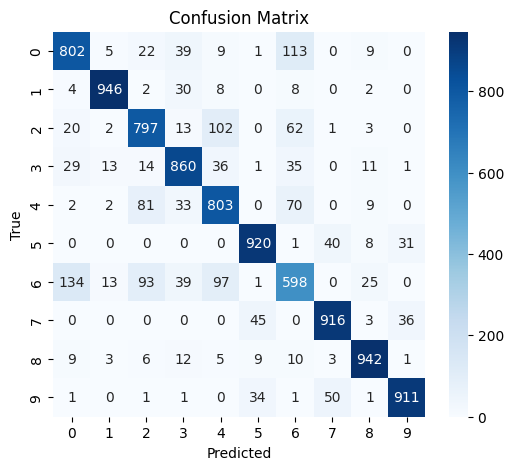

(np.float64(0.8495),
 0.8486725146399081,
 0.8484315431134142,
 0.8495,
 array([[802,   5,  22,  39,   9,   1, 113,   0,   9,   0],
        [  4, 946,   2,  30,   8,   0,   8,   0,   2,   0],
        [ 20,   2, 797,  13, 102,   0,  62,   1,   3,   0],
        [ 29,  13,  14, 860,  36,   1,  35,   0,  11,   1],
        [  2,   2,  81,  33, 803,   0,  70,   0,   9,   0],
        [  0,   0,   0,   0,   0, 920,   1,  40,   8,  31],
        [134,  13,  93,  39,  97,   1, 598,   0,  25,   0],
        [  0,   0,   0,   0,   0,  45,   0, 916,   3,  36],
        [  9,   3,   6,  12,   5,   9,  10,   3, 942,   1],
        [  1,   0,   1,   1,   0,  34,   1,  50,   1, 911]]))

In [14]:
edge_dataset = FashionDataset(X_train_edge, y_train, transform=None)
edge_loader = DataLoader(edge_dataset, batch_size=2048, shuffle=True, num_workers=2)
edge_model = BaselineANN().to(device)
train_model(edge_model, edge_loader, epochs=30, lr=0.001, save_best='best_fashion_edge.pth')
evaluate_model(edge_model, X_test_edge, y_test, num_classes=10, is_raw=False)

## Feature Engineering 2: Sobel Magnitude

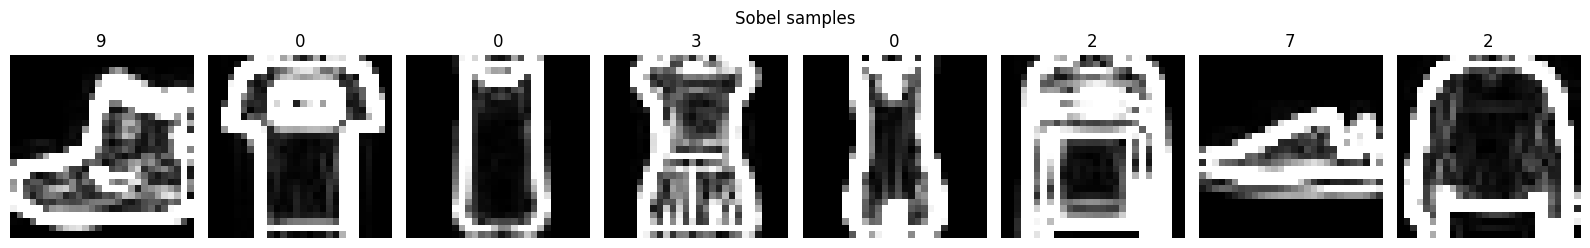

In [15]:
def sobel_mag(img):
    sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3) ** 2
    sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3) ** 2
    mag = np.sqrt(sx + sy)
    mag[mag > 255] = 255
    return mag.astype(np.uint8)

X_train_sobel = np.array([sobel_mag(img) for img in X_train], dtype=np.uint8)
X_test_sobel = np.array([sobel_mag(img) for img in X_test], dtype=np.uint8)

show_samples('Sobel samples', X_train_sobel[:8], y_train[:8])

Epoch 1/30 - Loss: 0.7730, Acc: 0.7822
Epoch 2/30 - Loss: 0.3836, Acc: 0.8744
Epoch 3/30 - Loss: 0.3055, Acc: 0.8957
Epoch 4/30 - Loss: 0.2624, Acc: 0.9087
Epoch 5/30 - Loss: 0.2318, Acc: 0.9178
Epoch 6/30 - Loss: 0.2047, Acc: 0.9277
Epoch 7/30 - Loss: 0.1750, Acc: 0.9391
Epoch 8/30 - Loss: 0.1542, Acc: 0.9459
Epoch 9/30 - Loss: 0.1352, Acc: 0.9532
Epoch 10/30 - Loss: 0.1227, Acc: 0.9567
Epoch 11/30 - Loss: 0.1070, Acc: 0.9634
Epoch 12/30 - Loss: 0.0853, Acc: 0.9710
Epoch 13/30 - Loss: 0.0693, Acc: 0.9777
Epoch 14/30 - Loss: 0.0670, Acc: 0.9780
Epoch 15/30 - Loss: 0.0515, Acc: 0.9838
Epoch 16/30 - Loss: 0.0475, Acc: 0.9846
Epoch 17/30 - Loss: 0.0383, Acc: 0.9878
Epoch 18/30 - Loss: 0.0363, Acc: 0.9888
Epoch 19/30 - Loss: 0.0299, Acc: 0.9914
Epoch 20/30 - Loss: 0.0231, Acc: 0.9937
Epoch 21/30 - Loss: 0.0208, Acc: 0.9941
Epoch 22/30 - Loss: 0.0176, Acc: 0.9955
Epoch 23/30 - Loss: 0.0144, Acc: 0.9960
Epoch 24/30 - Loss: 0.0153, Acc: 0.9956
Epoch 25/30 - Loss: 0.0247, Acc: 0.9918
Epoch 26/

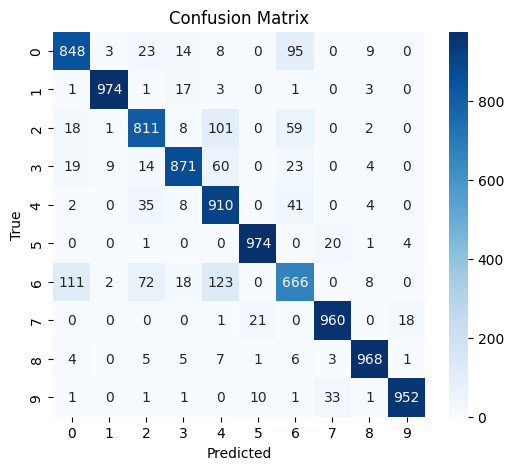

(np.float64(0.8934),
 0.8930941948819866,
 0.8950568918711935,
 0.8934,
 array([[848,   3,  23,  14,   8,   0,  95,   0,   9,   0],
        [  1, 974,   1,  17,   3,   0,   1,   0,   3,   0],
        [ 18,   1, 811,   8, 101,   0,  59,   0,   2,   0],
        [ 19,   9,  14, 871,  60,   0,  23,   0,   4,   0],
        [  2,   0,  35,   8, 910,   0,  41,   0,   4,   0],
        [  0,   0,   1,   0,   0, 974,   0,  20,   1,   4],
        [111,   2,  72,  18, 123,   0, 666,   0,   8,   0],
        [  0,   0,   0,   0,   1,  21,   0, 960,   0,  18],
        [  4,   0,   5,   5,   7,   1,   6,   3, 968,   1],
        [  1,   0,   1,   1,   0,  10,   1,  33,   1, 952]]))

In [16]:
sobel_dataset = FashionDataset(X_train_sobel, y_train, transform=None)
sobel_loader = DataLoader(sobel_dataset, batch_size=2048, shuffle=True, num_workers=2)
sobel_model = BaselineANN().to(device)
train_model(sobel_model, sobel_loader, epochs=30, lr=0.001, save_best='best_fashion_sobel.pth')
evaluate_model(sobel_model, X_test_sobel, y_test, num_classes=10, is_raw=False)

## Feature Engineering 3: HOG

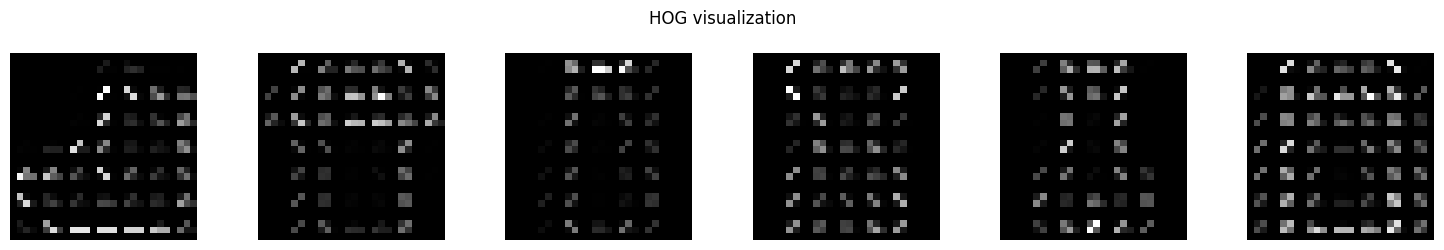

In [17]:
def extract_hog_features_cv2(images):
    images = images.reshape(-1, 28, 28)
    win_size = images[0].shape
    cell_size = (4, 4)
    block_size = (8, 8)
    block_stride = (4, 4)
    num_bins = 9
    hog_desc = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, num_bins)
    num_images = images.shape[0]
    feat_size = len(hog_desc.compute(images[0].astype(np.uint8)))
    feats = np.zeros((num_images, feat_size), dtype=np.float32)
    for i, img in enumerate(images):
        feats[i] = hog_desc.compute(img.astype(np.uint8)).flatten()
    return feats

def show_hog_visuals(images, n=6):
    n = min(n, len(images))
    plt.figure(figsize=(n * 2.5, 2.5))
    for i in range(n):
        _, hog_image = hog(images[i], orientations=9, pixels_per_cell=(4, 4),
                           cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)
        plt.subplot(1, n, i + 1)
        plt.imshow(hog_image, cmap='gray')
        plt.axis('off')
    plt.suptitle('HOG visualization')
    plt.tight_layout()
    plt.show()

show_hog_visuals(X_train[:6])

Epoch 1/30 - Loss: 0.6648, Acc: 0.8237
Epoch 2/30 - Loss: 0.3012, Acc: 0.9046
Epoch 3/30 - Loss: 0.2376, Acc: 0.9202
Epoch 4/30 - Loss: 0.1946, Acc: 0.9355
Epoch 5/30 - Loss: 0.1651, Acc: 0.9440
Epoch 6/30 - Loss: 0.1441, Acc: 0.9513
Epoch 7/30 - Loss: 0.1172, Acc: 0.9611
Epoch 8/30 - Loss: 0.0925, Acc: 0.9700
Epoch 9/30 - Loss: 0.0753, Acc: 0.9760
Epoch 10/30 - Loss: 0.0594, Acc: 0.9814
Epoch 11/30 - Loss: 0.0487, Acc: 0.9855
Epoch 12/30 - Loss: 0.0404, Acc: 0.9878
Epoch 13/30 - Loss: 0.0364, Acc: 0.9888
Epoch 14/30 - Loss: 0.0240, Acc: 0.9939
Epoch 15/30 - Loss: 0.0211, Acc: 0.9938
Epoch 16/30 - Loss: 0.0123, Acc: 0.9975
Epoch 17/30 - Loss: 0.0087, Acc: 0.9984
Epoch 18/30 - Loss: 0.0048, Acc: 0.9995
Epoch 19/30 - Loss: 0.0030, Acc: 0.9997
Epoch 20/30 - Loss: 0.0018, Acc: 0.9999
Epoch 21/30 - Loss: 0.0013, Acc: 1.0000
Epoch 22/30 - Loss: 0.0011, Acc: 1.0000
Epoch 23/30 - Loss: 0.0011, Acc: 1.0000
Epoch 24/30 - Loss: 0.0011, Acc: 0.9999
Epoch 25/30 - Loss: 0.0015, Acc: 0.9998
Epoch 26/

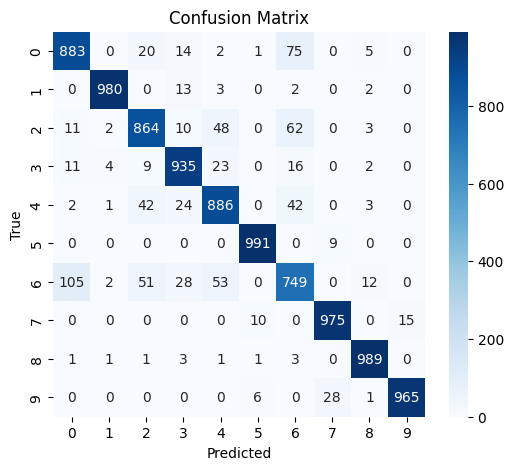

(np.float64(0.9217),
 0.9213145297611791,
 0.9211426235421455,
 0.9217,
 array([[883,   0,  20,  14,   2,   1,  75,   0,   5,   0],
        [  0, 980,   0,  13,   3,   0,   2,   0,   2,   0],
        [ 11,   2, 864,  10,  48,   0,  62,   0,   3,   0],
        [ 11,   4,   9, 935,  23,   0,  16,   0,   2,   0],
        [  2,   1,  42,  24, 886,   0,  42,   0,   3,   0],
        [  0,   0,   0,   0,   0, 991,   0,   9,   0,   0],
        [105,   2,  51,  28,  53,   0, 749,   0,  12,   0],
        [  0,   0,   0,   0,   0,  10,   0, 975,   0,  15],
        [  1,   1,   1,   3,   1,   1,   3,   0, 989,   0],
        [  0,   0,   0,   0,   0,   6,   0,  28,   1, 965]]))

In [18]:
X_train_hog = extract_hog_features_cv2(X_train)
X_test_hog = extract_hog_features_cv2(X_test)

hog_model = BaselineANN(input_size=X_train_hog.shape[1], hidden_size=512, output_size=10).to(device)
hog_loader = DataLoader(list(zip(torch.tensor(X_train_hog, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))),
                        batch_size=2048, shuffle=True, num_workers=2)
train_model(hog_model, hog_loader, epochs=30, lr=0.001, save_best='best_fashion_hog.pth')
evaluate_model(hog_model, X_test_hog, y_test, num_classes=10, is_raw=False)

## Notes

- Record accuracy, F1, precision, and recall after each feature stage.
- Include best confusion matrices in the report.